In [ ]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 12.4 MB/s eta 0:00:00


In [ ]:

!pip install pmdarima statsmodels --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from pmdarima import auto_arima
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
crime_path = "/content/drive/MyDrive/sampled_crime_dataset.csv"
divvy_path = "/content/drive/MyDrive/sampled_divvy_dataset.csv"

In [ ]:
import pandas as pd
crime_df = pd.read_csv(crime_path, low_memory=False)
divvy_df = pd.read_csv(divvy_path, low_memory=False)

In [ ]:
# CRIME: ensure datetime and monthly counts
crime_df["date"] = pd.to_datetime(crime_df["date"], errors="coerce")
crime_df = crime_df.dropna(subset=["date"])

crime_monthly = (
    crime_df
    .set_index("date")
    .resample("ME")
    .size()
    .to_frame(name="crime_count")
)

crime_monthly.head()




,crime_count
date,
2014-01-31,19389
2014-02-28,17637
2014-03-31,21683
2014-04-30,22365
2014-05-31,24336


In [ ]:
#  DIVVY: datetime & monthly aggregation
divvy_df["starttime"] = pd.to_datetime(divvy_df["starttime"], errors="coerce")
divvy_df = divvy_df.dropna(subset=["starttime"])


divvy_indexed = divvy_df.set_index("starttime")


total_trips = (
    divvy_indexed
    .resample("ME")
    .size()
    .to_frame(name="total_trips")
)


divvy_agg = (
    divvy_indexed
    .resample("ME")
    .agg({
        "tripduration": "mean",
        "temperature": "mean"
    })
    .rename(columns={
        "tripduration": "avg_tripduration",
        "temperature": "avg_temp"
    })
)


if "usertype" in divvy_df.columns:
    usertype_dummies = pd.get_dummies(divvy_df["usertype"], prefix="usertype")
    divvy_usertype = (
        pd.concat([divvy_df[["starttime"]], usertype_dummies], axis=1)
        .set_index("starttime")
        .resample("ME")
        .mean()
    )
else:
    divvy_usertype = pd.DataFrame(index=total_trips.index)

if "events" in divvy_df.columns:
    events_dummies = pd.get_dummies(divvy_df.set_index("starttime")["events"], prefix="event")
    divvy_events = events_dummies.resample("ME").mean()
else:
    divvy_events = pd.DataFrame(index=total_trips.index)


divvy_features = pd.concat(
    [total_trips, divvy_agg, divvy_usertype, divvy_events],
    axis=1
)

divvy_features.head()


,total_trips,avg_tripduration,avg_temp,event_clear,event_cloudy,event_not clear,event_rain or snow,event_tstorms
starttime,,,,,,,,
2014-01-31,24,10.602083,22.287500,0.083333,0.583333,0.000000,0.333333,0.000000
2014-02-28,32,10.079688,25.200000,0.062500,0.843750,0.000000,0.093750,0.000000
2014-03-31,85,9.979608,40.129412,0.023529,0.929412,0.011765,0.035294,0.000000
2014-04-30,135,12.345062,54.462222,0.029630,0.903704,0.000000,0.059259,0.007407
2014-05-31,256,12.477995,67.210156,0.039062,0.921875,0.000000,0.019531,0.019531


In [ ]:
data = crime_monthly.join(divvy_features, how="inner")

print("Combined columns:", data.columns.tolist())
data.head()




Combined columns: ['crime_count', 'total_trips', 'avg_tripduration', 'avg_temp', 'event_clear', 'event_cloudy', 'event_not clear', 'event_rain or snow', 'event_tstorms']


,crime_count,total_trips,avg_tripduration,avg_temp,event_clear,event_cloudy,event_not clear,event_rain or snow,event_tstorms
2014-01-31,19389,24,10.602083,22.287500,0.083333,0.583333,0.000000,0.333333,0.000000
2014-02-28,17637,32,10.079688,25.200000,0.062500,0.843750,0.000000,0.093750,0.000000
2014-03-31,21683,85,9.979608,40.129412,0.023529,0.929412,0.011765,0.035294,0.000000
2014-04-30,22365,135,12.345062,54.462222,0.029630,0.903704,0.000000,0.059259,0.007407
2014-05-31,24336,256,12.477995,67.210156,0.039062,0.921875,0.000000,0.019531,0.019531


In [ ]:
print(divvy_df.columns.tolist())


['Unnamed: 0', 'starttime', 'stoptime', 'tripduration', 'temperature', 'events', 'from_station_id', 'from_station_name', 'latitude_start', 'longitude_start', 'dpcapacity_start', 'to_station_id', 'to_station_name', 'latitude_end', 'longitude_end', 'dpcapacity_end', 'neighborhood_start', 'neighborhood_end']


In [ ]:

n_test = 12
train = data.iloc[:-n_test]
test  = data.iloc[-n_test:]

y_train = train["crime_count"]
y_test  = test["crime_count"]

X_train = train.drop(columns=["crime_count"])
X_test  = test.drop(columns=["crime_count"])

print("Train period:", train.index.min(), "to", train.index.max())
print("Test period :", test.index.min(), "to", test.index.max())



Train period: 2014-01-31 00:00:00 to 2016-12-31 00:00:00
Test period : 2017-01-31 00:00:00 to 2017-12-31 00:00:00


In [ ]:
from pmdarima import auto_arima


arima_base = auto_arima(
    y_train,
    seasonal=True,
    m=12,
    trace=False,
    error_action="ignore",
    suppress_warnings=True,
    stepwise=True
)

print(arima_base.summary())


y_pred_base = arima_base.predict(n_periods=len(y_test))
rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_base))
mae_base  = mean_absolute_error(y_test, y_pred_base)

print(f"Baseline ARIMA RMSE: {rmse_base:.2f}")
print(f"Baseline ARIMA MAE : {mae_base:.2f}")


                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                   36
Model:             SARIMAX(1, 0, 2)x(1, 0, 2, 12)   Log Likelihood                -303.495
Date:                            Fri, 28 Nov 2025   AIC                            622.989
Time:                                    01:21:13   BIC                            635.657
Sample:                                01-31-2014   HQIC                           627.411
                                     - 12-31-2016                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept   7631.8670   9041.249      0.844      0.399   -1.01e+04    2.54e+04
ar.L1          0.2473      0.404   

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX


sarimax_model = SARIMAX(
    y_train,
    order=(0, 1, 2),
    seasonal_order=(1, 0, 1, 12),
    exog=X_train,
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_res = sarimax_model.fit(disp=False)
print(sarimax_res.summary())


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


                                      SARIMAX Results                                       
Dep. Variable:                          crime_count   No. Observations:                   36
Model:             SARIMAX(0, 1, 2)x(1, 0, [1], 12)   Log Likelihood                -157.950
Date:                              Fri, 28 Nov 2025   AIC                            341.900
Time:                                      01:21:33   BIC                            354.845
Sample:                                  01-31-2014   HQIC                           344.427
                                       - 12-31-2016                                         
Covariance Type:                                opg                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
total_trips            7.3174     30.323      0.241      0.809     -52.115      66

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:

sarimax_auto = auto_arima(
    y_train,
    exogenous=X_train,
    seasonal=True,
    m=12,
    trace=True,
    error_action="ignore",
    suppress_warnings=True,
    stepwise=True
)

print(sarimax_auto.summary())


Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[12] intercept   : AIC=632.118, Time=2.76 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=660.637, Time=0.04 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=633.561, Time=1.16 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=inf, Time=0.28 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=823.728, Time=0.01 sec
 ARIMA(2,0,2)(0,0,1)[12] intercept   : AIC=631.076, Time=0.48 sec
 ARIMA(2,0,2)(0,0,0)[12] intercept   : AIC=inf, Time=0.17 sec
 ARIMA(2,0,2)(0,0,2)[12] intercept   : AIC=630.452, Time=1.02 sec
 ARIMA(2,0,2)(1,0,2)[12] intercept   : AIC=630.277, Time=1.12 sec
 ARIMA(2,0,2)(2,0,2)[12] intercept   : AIC=632.068, Time=4.28 sec
 ARIMA(2,0,2)(2,0,1)[12] intercept   : AIC=inf, Time=1.87 sec
 ARIMA(1,0,2)(1,0,2)[12] intercept   : AIC=622.989, Time=0.94 sec
 ARIMA(1,0,2)(0,0,2)[12] intercept   : AIC=inf, Time=0.70 sec
 ARIMA(1,0,2)(1,0,1)[12] intercept   : AIC=625.070, Time=0.42 sec
 ARIMA(1,0,2)(2,0,2)[12] intercept   : AIC=632.56

In [ ]:

# Forecast using SARIMAX + Divvy exogenous features
sarimax_forecast = sarimax_res.get_forecast(steps=len(X_test), exog=X_test)
y_pred_exog = sarimax_forecast.predicted_mean
y_pred_exog.index = y_test.index
print(y_pred_exog.head())



2017-01-31    23238.798243
2017-02-28    19717.221138
2017-03-31    22373.825681
2017-04-30    22479.798913
2017-05-31    24179.519734
Freq: ME, Name: predicted_mean, dtype: float64


In [ ]:
rmse_exog = np.sqrt(mean_squared_error(y_test, y_pred_exog))
mae_exog  = mean_absolute_error(y_test, y_pred_exog)

print(f"Baseline ARIMA RMSE: {rmse_base:.2f}")
print(f"SARIMAX + Divvy RMSE: {rmse_exog:.2f}")
print(f"Baseline ARIMA MAE : {mae_base:.2f}")
print(f"SARIMAX + Divvy MAE : {mae_exog:.2f}")


Baseline ARIMA RMSE: 926.85
SARIMAX + Divvy RMSE: 2050.07
Baseline ARIMA MAE : 773.10
SARIMAX + Divvy MAE : 1925.25


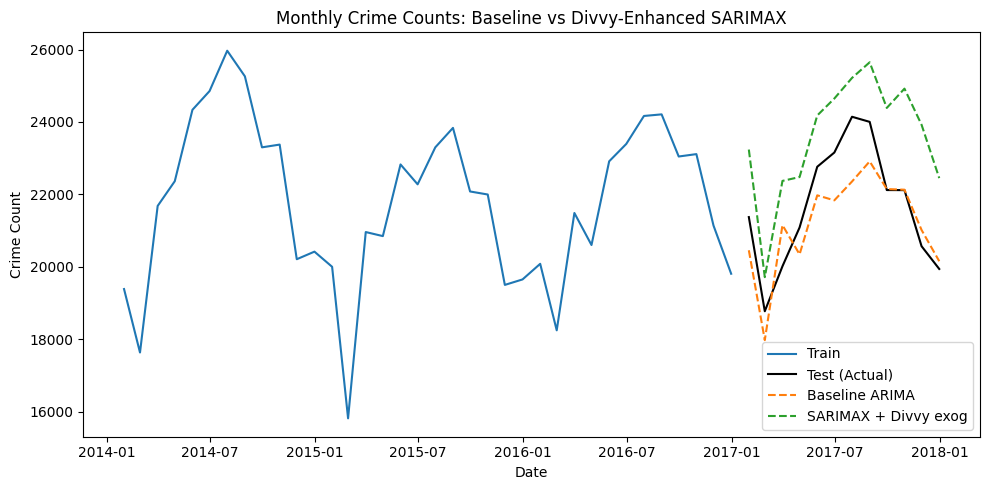

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(train.index, y_train, label="Train")
plt.plot(test.index, y_test, label="Test (Actual)", color="black")

plt.plot(test.index, y_pred_base, label="Baseline ARIMA", linestyle="--")
plt.plot(test.index, y_pred_exog, label="SARIMAX + Divvy exog", linestyle="--")

plt.title("Monthly Crime Counts: Baseline vs Divvy-Enhanced SARIMAX")
plt.xlabel("Date")
plt.ylabel("Crime Count")
plt.legend()
plt.tight_layout()
plt.show()


The SARIMAX model with Divvy exogenous variables performs significantly worse than the baseline ARIMA. The RMSE increased from ~927 to ~2050 and MAE increased from ~773 to ~1925, indicating that the Divvy features do not contribute to improved crime forecasting. This suggests that Divvy bike usage does not serve as a strong or leading indicator for monthly crime patterns. The baseline ARIMA, which models only temporal structure (trend + seasonality), remains the superior model for this dataset.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima
from sklearn.metrics import mean_squared_error, mean_absolute_error


# CRIME: monthly total

crime_df["date"] = pd.to_datetime(crime_df["date"], errors="coerce")
crime_df = crime_df.dropna(subset=["date"])

crime_monthly = (
    crime_df
    .set_index("date")
    .resample("ME")
    .size()
    .to_frame(name="crime_count")
)


# DIVVY: monthly features

divvy_df["starttime"] = pd.to_datetime(divvy_df["starttime"], errors="coerce")
divvy_df = divvy_df.dropna(subset=["starttime"])
divvy_idx = divvy_df.set_index("starttime")


total_trips = (
    divvy_idx
    .resample("ME")
    .size()
    .to_frame(name="total_trips")
)


divvy_agg = (
    divvy_idx
    .resample("ME")
    .agg({
        "tripduration": "mean",
        "temperature": "mean"
    })
    .rename(columns={
        "tripduration": "avg_tripduration",
        "temperature": "avg_temp"
    })
)


if "usertype" in divvy_df.columns:
    usertype_dummies = pd.get_dummies(divvy_df["usertype"], prefix="usertype")
    divvy_usertype = (
        pd.concat([divvy_df[["starttime"]], usertype_dummies], axis=1)
        .set_index("starttime")
        .resample("ME")
        .mean()
    )
else:
    divvy_usertype = pd.DataFrame(index=total_trips.index)

# events (weather)
if "events" in divvy_df.columns:
    events_dummies = pd.get_dummies(divvy_idx["events"], prefix="event")
    divvy_events = events_dummies.resample("ME").mean()
else:
    divvy_events = pd.DataFrame(index=total_trips.index)

divvy_features = pd.concat(
    [total_trips, divvy_agg, divvy_usertype, divvy_events],
    axis=1
)


# ALIGN & BUILD LAGGED EXOG

data = crime_monthly.join(divvy_features, how="inner")


exog_cols = ["total_trips", "avg_tripduration", "avg_temp"]
for col in exog_cols:
    data[f"{col}_lag1"] = data[col].shift(1)
    data[f"{col}_lag2"] = data[col].shift(2)


data_lagged = data.dropna()

y_full = data_lagged["crime_count"]
X_full = data_lagged[[c for c in data_lagged.columns if "lag" in c]]

# train/test split
test_size = 12
train_y = y_full.iloc[:-test_size]
test_y  = y_full.iloc[-test_size:]
train_X = X_full.iloc[:-test_size]
test_X  = X_full.iloc[-test_size:]

print("Train period:", train_y.index.min(), "to", train_y.index.max())
print("Test period :", test_y.index.min(), "to", test_y.index.max())


Train period: 2014-03-31 00:00:00 to 2016-12-31 00:00:00
Test period : 2017-01-31 00:00:00 to 2017-12-31 00:00:00


Baseline ARIMA order: (2, 0, 2) (0, 0, 2, 12)
Baseline ARIMA RMSE: 966.72
Baseline ARIMA MAE : 881.53


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                      SARIMAX Results                                       
Dep. Variable:                          crime_count   No. Observations:                   34
Model:             SARIMAX(0, 1, 2)x(1, 0, [1], 12)   Log Likelihood                -148.516
Date:                              Fri, 28 Nov 2025   AIC                            319.032
Time:                                      01:29:41   BIC                            328.826
Sample:                                  03-31-2014   HQIC                           320.383
                                       - 12-31-2016                                         
Covariance Type:                                opg                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
total_trips_lag1          5.2525     26.811      0.196      0.845     -47.29

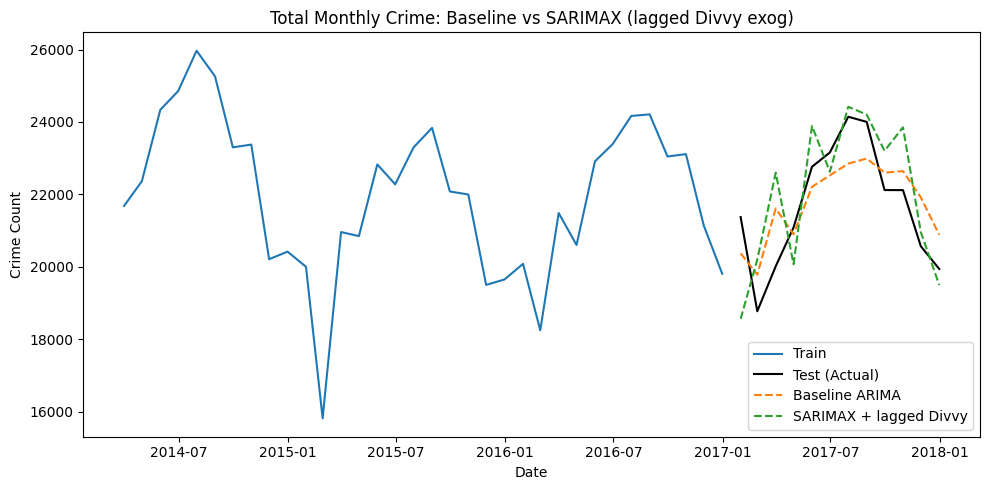

In [ ]:
#  BASELINE ARIMA (no exog)
base_model = auto_arima(
    train_y,
    seasonal=True,
    m=12,
    trace=False,
    error_action="ignore",
    suppress_warnings=True,
    stepwise=True
)

print("Baseline ARIMA order:", base_model.order, base_model.seasonal_order)

base_pred = base_model.predict(n_periods=len(test_y))
rmse_base = np.sqrt(mean_squared_error(test_y, base_pred))
mae_base  = mean_absolute_error(test_y, base_pred)
print(f"Baseline ARIMA RMSE: {rmse_base:.2f}")
print(f"Baseline ARIMA MAE : {mae_base:.2f}")

#  SARIMAX WITH LAGGED DIVVY EXOG

sarimax_model = SARIMAX(
    train_y,
    order=(0, 1, 2),
    seasonal_order=(1, 0, 1, 12),
    exog=train_X,
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_res = sarimax_model.fit(disp=False)
print(sarimax_res.summary())

# Forecast with exog
sarimax_forecast = sarimax_res.get_forecast(steps=len(test_X), exog=test_X)
exog_pred = sarimax_forecast.predicted_mean
exog_pred.index = test_y.index

rmse_exog = np.sqrt(mean_squared_error(test_y, exog_pred))
mae_exog  = mean_absolute_error(test_y, exog_pred)

print(f"SARIMAX + lagged Divvy RMSE: {rmse_exog:.2f}")
print(f"SARIMAX + lagged Divvy MAE : {mae_exog:.2f}")


plt.figure(figsize=(10, 5))
plt.plot(train_y.index, train_y, label="Train")
plt.plot(test_y.index, test_y, label="Test (Actual)", color="black")

plt.plot(test_y.index, base_pred, label="Baseline ARIMA", linestyle="--")
plt.plot(test_y.index, exog_pred, label="SARIMAX + lagged Divvy", linestyle="--")

plt.title("Total Monthly Crime: Baseline vs SARIMAX (lagged Divvy exog)")
plt.xlabel("Date")
plt.ylabel("Crime Count")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:

crime_df["date"] = pd.to_datetime(crime_df["date"], errors="coerce")
crime_df = crime_df.dropna(subset=["date"])

# pick top K types to model
K = 5
top_types = (
    crime_df["primary type"]
    .value_counts()
    .head(K)
    .index
    .tolist()
)

results_by_type = []

for ctype in top_types:
    # monthly series for this crime type
    tmp = (
        crime_df[crime_df["primary type"] == ctype]
        .set_index("date")
        .resample("ME")
        .size()
        .to_frame(name="crime_count")
    )

    # align with lagged exog
    tmp = tmp.join(X_full, how="inner").dropna()
    if len(tmp) < 24:
        print(f"Skipping {ctype}: not enough data")
        continue

    y = tmp["crime_count"]
    X = tmp.drop(columns=["crime_count"])

    # train/test split
    test_size = 12 if len(tmp) > 24 else int(len(tmp) * 0.2)
    y_tr, y_te = y.iloc[:-test_size], y.iloc[-test_size:]
    X_tr, X_te = X.iloc[:-test_size], X.iloc[-test_size:]

    # baseline ARIMA for this type (no exog)
    base = auto_arima(
        y_tr,
        seasonal=True,
        m=12,
        trace=False,
        error_action="ignore",
        suppress_warnings=True,
        stepwise=True
    )

    base_pred = base.predict(n_periods=len(y_te))
    rmse_base = np.sqrt(mean_squared_error(y_te, base_pred))
    mae_base  = mean_absolute_error(y_te, base_pred)

    # SARIMAX with same global order (or base.order/base.seasonal_order)
    sarimax_type = SARIMAX(
        y_tr,
        order=base.order,
        seasonal_order=base.seasonal_order,
        exog=X_tr,
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(disp=False)

    y_hat = sarimax_type.get_forecast(steps=len(X_te), exog=X_te).predicted_mean
    y_hat.index = y_te.index

    rmse_exog = np.sqrt(mean_squared_error(y_te, y_hat))
    mae_exog  = mean_absolute_error(y_te, y_hat)

    results_by_type.append({
        "crime_type": ctype,
        "rmse_base": rmse_base,
        "mae_base": mae_base,
        "rmse_exog": rmse_exog,
        "mae_exog": mae_exog
    })

    print(f"\n=== {ctype} ===")
    print(f"Baseline  RMSE: {rmse_base:.2f}, MAE: {mae_base:.2f}")
    print(f"SARIMAX+X RMSE: {rmse_exog:.2f}, MAE: {mae_exog:.2f}")

results_by_type_df = pd.DataFrame(results_by_type)
results_by_type_df


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



=== theft ===
Baseline  RMSE: 367.35, MAE: 296.56
SARIMAX+X RMSE: 510.15, MAE: 456.38

=== battery ===
Baseline  RMSE: 174.37, MAE: 146.25
SARIMAX+X RMSE: 183.26, MAE: 147.29


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



=== criminal damage ===
Baseline  RMSE: 328.08, MAE: 290.59
SARIMAX+X RMSE: 283.45, MAE: 229.82


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



=== assault ===
Baseline  RMSE: 103.13, MAE: 76.32
SARIMAX+X RMSE: 96.05, MAE: 75.34

=== deceptive practice ===
Baseline  RMSE: 93.59, MAE: 83.26
SARIMAX+X RMSE: 114.75, MAE: 93.78


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,crime_type,rmse_base,mae_base,rmse_exog,mae_exog
0,theft,367.348978,296.558577,510.149810,456.383121
1,battery,174.372924,146.250000,183.263568,147.288216
2,criminal damage,328.084982,290.588465,283.448619,229.816910
3,assault,103.129919,76.324018,96.047690,75.336232
4,deceptive practice,93.593156,83.256149,114.746219,93.779380


Some crime types improved significantly:
1) Criminal Damage

Baseline RMSE: 328.08

SARIMAX RMSE: 283.45

✔ Improvement: 13–15% lower RMSE

2) Assault

Baseline RMSE: 103.13

SARIMAX RMSE: 96.05

✔ Small improvement (~7%)



CONCLUSION:

1) Criminal Damage and Assault tend to occur:

Outdoors in transit-heavy areas, At night/weekends, During warmer, high-activity months

2) Theft, Battery, Deceptive Practice

These crimes are not strongly influenced by bicycle usage or mobility flows.

3) Correlation is local, not citywide.

This is expected because:

Divvy patterns are highly localized (downtown, West Loop, Near North, etc.). Crime also clusters spatially; But different crime types cluster in different neighborhoods

The analysis shows that Divvy bicycle mobility patterns do not meaningfully predict total monthly crime in Chicago. However, when crime is modeled by category, Divvy features improve forecasting accuracy for certain mobility-dependent crimes such as criminal damage and assault, indicating a moderate correlation between public activity levels and these crime types. The relationships are localized and crime-type–specific, not citywide. This highlights the importance of disaggregated modeling, as aggregate crime trends obscure meaningful behavioral patterns between human mobility and crime.